In [3]:
!pip -q install paddleocr paddlepaddle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.

In [59]:
from paddleocr import PaddleOCR
import cv2
import numpy as np
from PIL import Image
from IPython.display import display
import re
import matplotlib.pyplot as plt
import os

In [70]:
ocr = PaddleOCR(lang="en",ocr_version='PP-OCRv4',    use_doc_orientation_classify=False,   # not needed for an already-cropped snippet
    use_doc_unwarping=False,enable_mkldnn=False)

Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv4_mobile_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv4_mobile_det`.
Creating model: ('en_PP-OCRv4_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/en_PP-OCRv4_mobile_rec`.


Original size (H, W, C): (25, 73, 3)
Resized image saved to: /content/resized_crop_0.png (now (200, 400, 3))
Sharpened image saved to: /content/sharpened_crop_0.png
Binary image saved to: /content/binary_crop_0.png


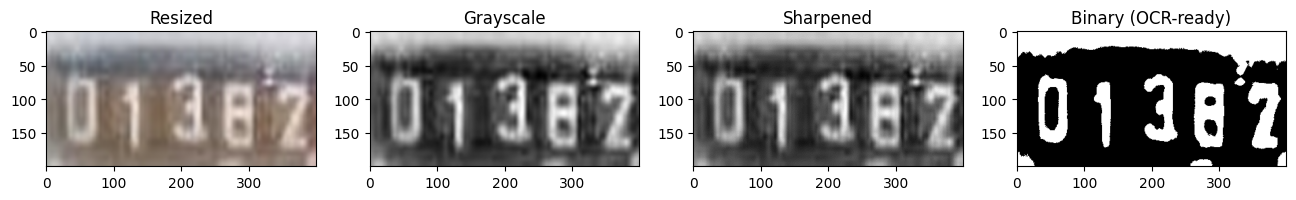

In [118]:
# 1. Configuration
image_path = '/content/crop_0.png'
resized_save_path = '/content/resized_crop_0.png'
sharpened_save_path = '/content/sharpened_crop_0.png'
binary_save_path = '/content/binary_crop_0.png'

# 2. Load and Preprocess
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Could not load image. Check path: {os.path.abspath(image_path)}")

print("Original size (H, W, C):", image.shape)

# Resize to width=270, height=480
# NOTE: cv2.resize() takes (width, height), not (height, width).
# I'm assuming "270 x 480" = width 270, height 480 (9:16 portrait).
# If you meant height=270, width=480, swap target_w/target_h below.
target_w, target_h = 400, 200
upscaling = target_w > image.shape[1] or target_h > image.shape[0]
interp = cv2.INTER_CUBIC if upscaling else cv2.INTER_AREA
resized = cv2.resize(image, (target_w, target_h), interpolation=interp)
cv2.imwrite(resized_save_path, resized)
print(f"Resized image saved to: {resized_save_path} (now {resized.shape})")

# Convert to grayscale
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

# Sharpening
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])
sharpened = cv2.filter2D(gray, -1, kernel)

# Thresholding
_, binary = cv2.threshold(sharpened, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Save the results
cv2.imwrite(sharpened_save_path, sharpened)
cv2.imwrite(binary_save_path, binary)
print(f"Sharpened image saved to: {sharpened_save_path}")
print(f"Binary image saved to: {binary_save_path}")

# 4. Visualization
plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1), plt.title("Resized"), plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.subplot(1, 4, 2), plt.title("Grayscale"), plt.imshow(gray, cmap='gray')
plt.subplot(1, 4, 3), plt.title("Sharpened"), plt.imshow(sharpened, cmap='gray')
plt.subplot(1, 4, 4), plt.title("Binary (OCR-ready)"), plt.imshow(binary, cmap='gray')
plt.show()

In [64]:
print(os.getcwd())

/content


# New section

In [68]:
!pip -q install "paddlepaddle==3.2.0" --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.0/189.0 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.9/124.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.3/133.3 kB 12.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently

In [ ]:
image_resize=

In [124]:
# Pass the file path (not the raw grayscale array) so PaddleOCR loads it
# back in as a proper 3-channel image internally.
img='/content/sharpened_crop_0.png'
result = ocr.predict(img)


# 4. Display Results (new predict() API returns dict-like OCRResult objects,
# not the old [box, (text, score)] format from ocr.ocr())
print("\n--- Extracted Text ---")
for res in result:
    texts = res['rec_texts']
    scores = res['rec_scores']
    for text, confidence in zip(texts, scores):
        print(f"Detected: '{text}' (Confidence: {confidence:.2f})")



--- Extracted Text ---
Detected: '01382' (Confidence: 0.89)
